In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = Path('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}.")

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## DESCRIPTION GLOBALE DU DATASET

On veut comprendre :
- le type de chaque colonne,  
- le nombre de valeurs non nulles,  
- les éventuelles valeurs manquantes,  
- les éventuels doublons.

In [3]:
df.info()
df.describe(include='all')
print(f"Missing values:\n{df.isna().sum()}")
print(f"Duplicated rows: {df.duplicated().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

- `TotalCharges` contient des valeurs manquantes (type `object` ou `float` suivant la version).  
- `Churn` est une variable catégorielle binaire (`Yes` / `No`).  
- Aucun doublon ou très peu de doublons.  

## RÉPARTITION DE LA CIBLE CHURN

Analyse de la distribution de la variable cible.

Churn distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


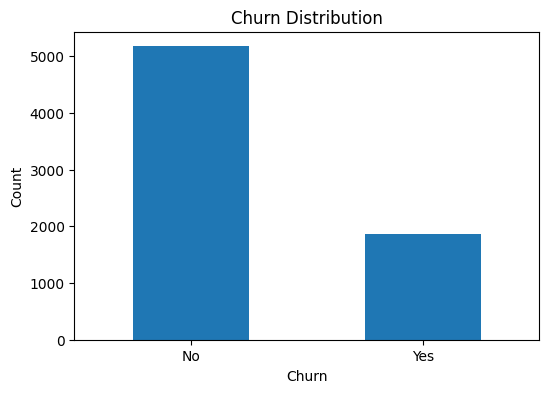

In [4]:
print("Churn distribution:")
print(df['Churn'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Variables numériques principales

On se concentre sur les 3 colonnes numériques les plus importantes :  
- `tenure` : ancienneté en mois,  
- `MonthlyCharges` : charges mensuelles,  
- `TotalCharges` : charges totales depuis le début.

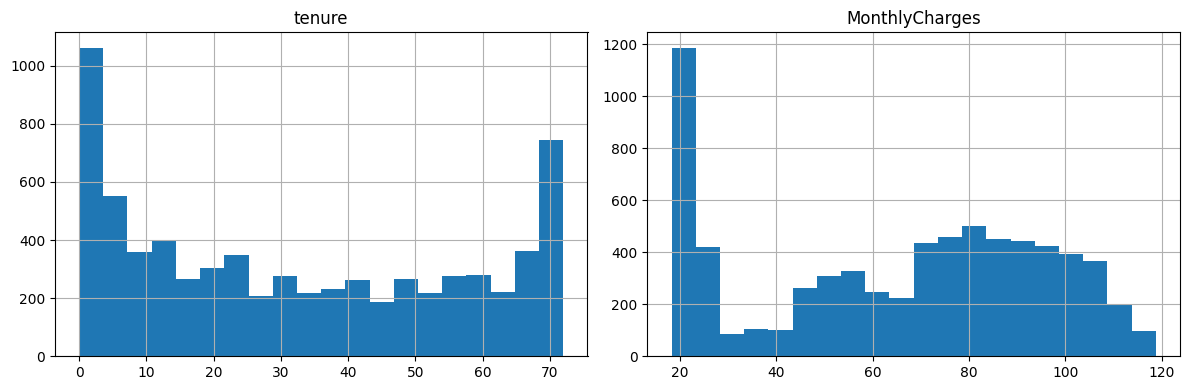

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].hist(bins=20, figsize=(12,4))
plt.tight_layout()
plt.show()

- `tenure` suit une loi de puissance : beaucoup de clients sont récents, peu restent longtemps.  
- `MonthlyCharges` est plutôt normale, centrée autour de 70–80.  
- `TotalCharges` a des valeurs manquantes et suit logiquement `tenure * MonthlyCharges`. 

# Churn en fonction des variables numériques

On utilise des boxplots pour voir comment `Churn` se répartit selon `tenure`, `MonthlyCharges` et `TotalCharges`.  
Cela permet déjà d’identifier des tendances fortes :
- clients qui restent plus longtemps,  
- clients qui payent plus cher, etc.

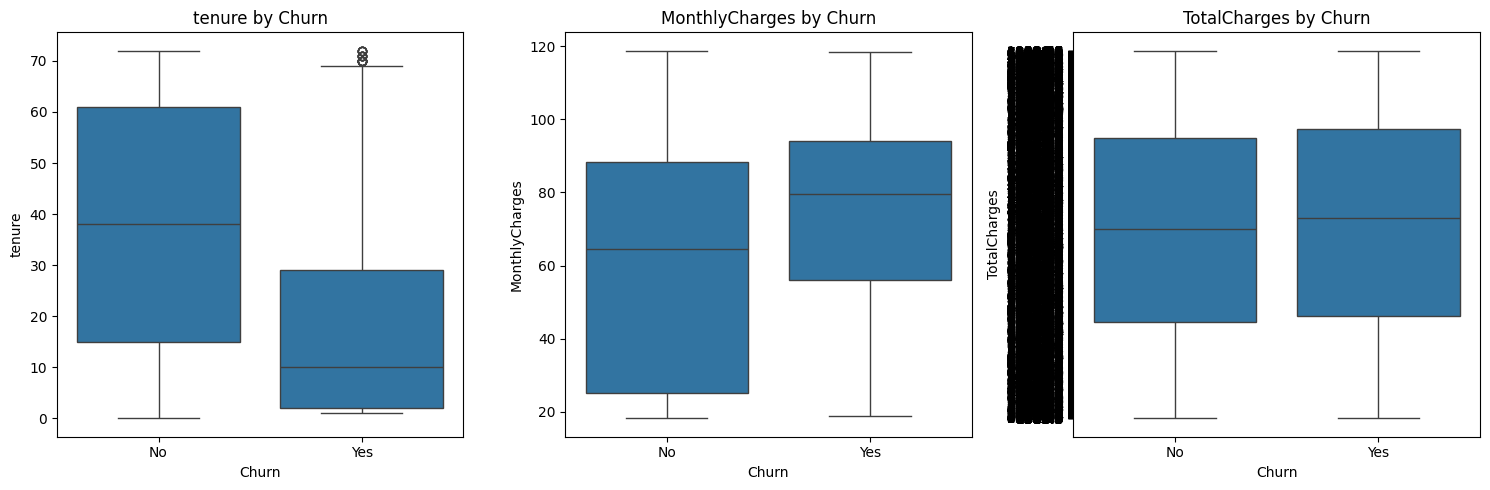

In [6]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

- `tenure` : les clients qui churn ont souvent un faible ancienneté.  
- `MonthlyCharges` : ce sont souvent les clients avec des charges élevées qui partent.  
- `TotalCharges` : les clients récents ont un total plus faible, ce qui est attendu.  

# Variables catégorielles importantes

On analyse les principales variables catégorielles qui ont un impact sur le churn :  
- `gender`, `SeniorCitizen`, `Partner`, `Dependents`,  
- `Contract`, `PaymentMethod`, `InternetService`.

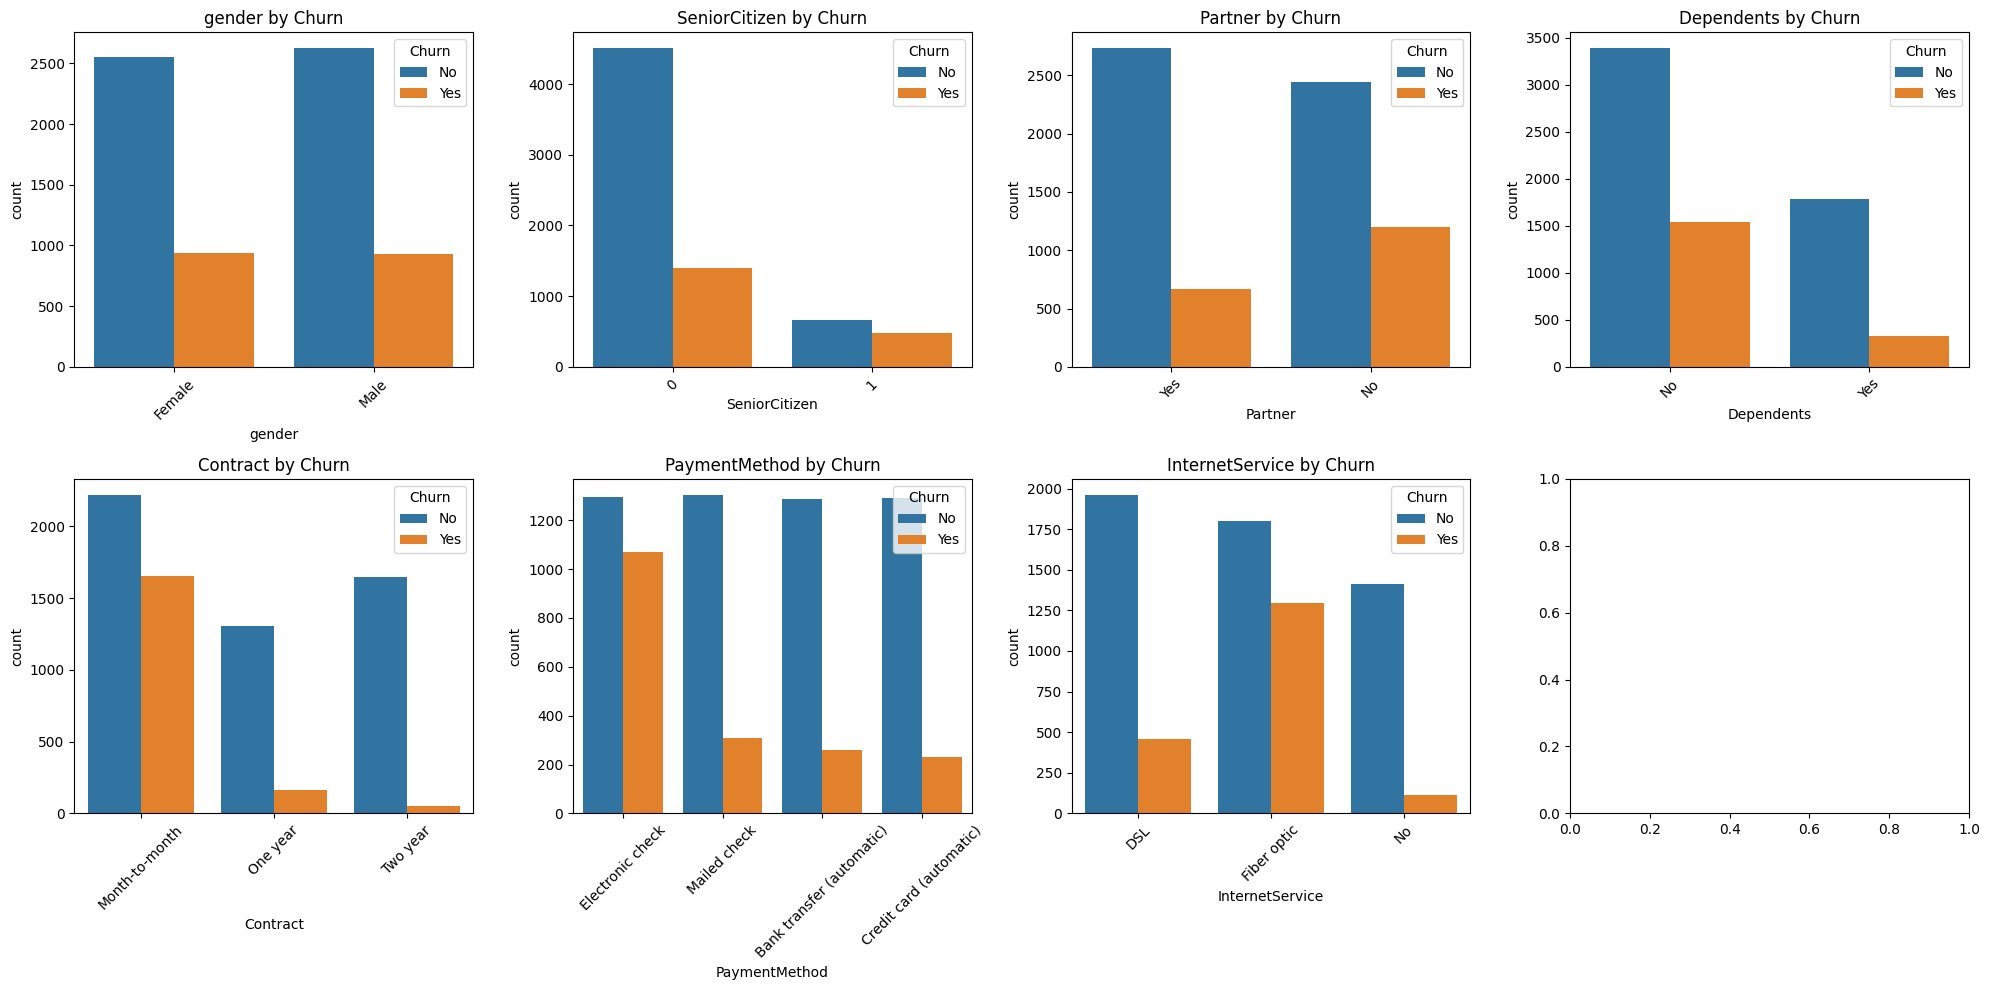

In [7]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'Contract', 'PaymentMethod', 'InternetService']
fig, axes = plt.subplots(2,4, figsize=(20,10))
for i, col in enumerate(cat_cols):
    row, col_idx = divmod(i,4)
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[row,col_idx])
    axes[row,col_idx].set_title(f'{col} by Churn')
    axes[row,col_idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Les seniors, les clients sans partenaire, les clients avec **fibre optique** , ceux avec contrat **month-to-month** et paiement **Electronic check** ont un taux de churn plus élevé.  
